# Part 5 — Guardrail Pipeline
Design and implement a three-layer production guardrail pipeline:
- Layer 1: Regex pre-filter (fast, rule-based)
- Layer 2: Calibrated model (best mitigated model from Part 4)
- Layer 3: Human review queue (uncertain cases)

In [44]:
import os, re, pickle, warnings, subprocess, sys
subprocess.run([sys.executable, "-m", "pip", "install", "-q", "aif360", "fairlearn"], check=False)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from sklearn.isotonic import IsotonicRegression
from sklearn.model_selection import train_test_split as sk_split
from sklearn.metrics import f1_score, precision_score, recall_score
from transformers import AutoTokenizer, AutoModelForSequenceClassification

warnings.filterwarnings("ignore")

SEED       = 42
DEVICE     = torch.device("cuda" if torch.cuda.is_available() else "cpu")
MODEL_DIR  = "/kaggle/working/part4_best_model"
MAX_LENGTH = 128
BATCH_SIZE = 64

print(f"Device: {DEVICE}")

Device: cuda


In [45]:
# ── Load eval set ──
eval_df = pd.read_csv("/kaggle/input/datasets/irtizaab/part-1-data/kaggle/working/eval_df.csv")
eval_df["label"] = (eval_df["toxic"] >= 0.5).astype(int)
print(f"Eval set: {len(eval_df):,} rows")

# ── Load model and tokenizer ──
tokenizer = AutoTokenizer.from_pretrained(MODEL_DIR)
model     = AutoModelForSequenceClassification.from_pretrained(MODEL_DIR)
model.to(DEVICE)
model.eval()
print("Best mitigated model loaded.")

Eval set: 20,000 rows


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Best mitigated model loaded.


In [46]:
def get_raw_probs(texts, batch_size=BATCH_SIZE):
    """Get raw softmax toxic probabilities for a list of texts."""
    all_probs = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i : i + batch_size]
        enc   = tokenizer(batch, max_length=MAX_LENGTH, truncation=True,
                          padding=True, return_tensors="pt").to(DEVICE)
        with torch.no_grad():
            logits = model(**enc).logits
        probs = torch.softmax(logits, dim=-1)[:, 1].cpu().numpy()
        all_probs.append(probs)
    return np.concatenate(all_probs)

## Layer 1 — Input Filter (Regex Pre-filter)

In [47]:
BLOCKLIST = {
    "direct_threat": [
        re.compile(r"\bi\s+(will|'ll|am\s+going\s+to|gonna|would)\s+(kill|murder|shoot|stab|hurt|destroy|end)\s+(you|u|him|her|them|your\s+\w+)\b", re.IGNORECASE),
        re.compile(r"\b(you're|you\s+are|ur)\s+going\s+to\s+(die|get\s+hurt|get\s+shot|get\s+killed)\b", re.IGNORECASE),
        re.compile(r"\bsomeone\s+should\s+(kill|shoot|stab|hurt|murder)\s+(you|him|her|them)\b", re.IGNORECASE),
        re.compile(r"\bi('ll|\s+will)\s+find\s+(you|where\s+you\s+live|your\s+address)\b", re.IGNORECASE),
        re.compile(r"\b(i\s+hope|hope)\s+you\s+(die|get\s+killed|suffer|rot)\b", re.IGNORECASE),
        re.compile(r"\b(?P<verb>kill|murder|shoot|stab|hurt)\s+you\b", re.IGNORECASE),
    ],
    "self_harm_directed": [
        re.compile(r"\byou\s+should\s+(kill|hang|cut|hurt)\s+yourself\b", re.IGNORECASE),
        re.compile(r"\bgo\s+kill\s+yourself\b", re.IGNORECASE),
        re.compile(r"\bnobody\s+(would\s+miss|will\s+miss|cares\s+if)\s+you\b", re.IGNORECASE),
        re.compile(r"\bdo\s+(everyone|the\s+world)\s+a\s+(favour|favor)\s+and\s+(disappear|die|kill\s+yourself)\b", re.IGNORECASE),
    ],
    "doxxing_stalking": [
        re.compile(r"\bi\s+know\s+where\s+you\s+live\b", re.IGNORECASE),
        re.compile(r"\bi('ll|\s+will|'m\s+gonna)\s+post\s+your\s+(address|info|details|number)\b", re.IGNORECASE),
        re.compile(r"\bi\s+found\s+your\s+(real\s+name|address|location|number)\b", re.IGNORECASE),
        re.compile(r"\beveryone\s+will\s+know\s+who\s+you\s+(really\s+are|are)\b", re.IGNORECASE),
    ],
    "dehumanization": [
        re.compile(r"\b(?:humans?|people|persons?)\b.{0,30}\bnot\s+(?:human|real\s+people|people)\b", re.IGNORECASE),
        re.compile(r"\b(?:they|those\s+people|(?:immigrants?|refugees?|muslims?|jews?|blacks?|whites?))\s+are\s+(?:animals?|parasites?|vermin|subhuman|not\s+human)\b", re.IGNORECASE),
        re.compile(r"\b(?:immigrants?|refugees?|muslims?|jews?|blacks?|whites?|(?:human|people|persons?))\s+should\s+be\s+exterminated\b", re.IGNORECASE),
        re.compile(r"\b(?:they|those\s+(?:people|humans?))\s+are\s+a\s+disease\b", re.IGNORECASE),
    ],
    "coordinated_harassment": [
        re.compile(r"\beveryone\s+report\s+(?:this\s+)?@?\w+\b", re.IGNORECASE),
        re.compile(r"\blet'?s?\s+(all\s+)?go\s+after\s+@?\w+\b", re.IGNORECASE),
        re.compile(r"\braid\s+(their\s+)?(profile|account|stream|page)\b", re.IGNORECASE),
        re.compile(r"\bmass\s+report\s+(this\s+)?(account|user|profile)\b", re.IGNORECASE),
        re.compile(r"\b(?:let'?s?|we\s+should)\s+(?=.{0,20}(?:spam|flood|target|harass))", re.IGNORECASE),
    ],
}

def input_filter(text: str):
    """Returns a block decision dict if matched, else None."""
    for category, patterns in BLOCKLIST.items():
        for pattern in patterns:
            if pattern.search(text):
                return {
                    "decision"  : "block",
                    "layer"     : "input_filter",
                    "category"  : category,
                    "confidence": 1.0,
                }
    return None

# Quick sanity check
test_cases = [
    "I will kill you if you do that again",
    "go kill yourself nobody cares",
    "I know where you live and I'll post your address",
    "they are not human, they are animals",
    "everyone report this account",
    "I really enjoyed the movie last night",
    "let's discuss the biology of parasites",
]
print("=== Input Filter Tests ===")
for t in test_cases:
    result = input_filter(t)
    status = f"BLOCKED ({result['category']})" if result else "ALLOWED"
    print(f"  {status:35s} | {t[:55]}")

=== Input Filter Tests ===
  BLOCKED (direct_threat)             | I will kill you if you do that again
  BLOCKED (self_harm_directed)        | go kill yourself nobody cares
  BLOCKED (doxxing_stalking)          | I know where you live and I'll post your address
  BLOCKED (dehumanization)            | they are not human, they are animals
  BLOCKED (coordinated_harassment)    | everyone report this account
  ALLOWED                             | I really enjoyed the movie last night
  ALLOWED                             | let's discuss the biology of parasites


## Layer 2 — Calibrated Model

In [48]:
# Split eval set 50/50: half for calibration fitting, half kept for demo
cal_idx, val_idx = sk_split(
    np.arange(len(eval_df)), test_size=0.5,
    stratify=eval_df["label"].values, random_state=SEED
)

cal_texts  = eval_df.iloc[cal_idx]["comment_text"].tolist()
cal_labels = eval_df.iloc[cal_idx]["label"].values

print("Computing raw probabilities for calibration set …")
cal_probs_raw = get_raw_probs(cal_texts)

# Fit isotonic calibration
calibrator = IsotonicRegression(out_of_bounds="clip")
calibrator.fit(cal_probs_raw, cal_labels)
print("Isotonic calibrator fitted.")

# ── Save calibrator for pipeline.py ──
with open("/kaggle/working/calibrator.pkl", "wb") as f:
    pickle.dump(calibrator, f)
print("Saved calibrator.pkl")

Computing raw probabilities for calibration set …
Isotonic calibrator fitted.
Saved calibrator.pkl


## Full ModerationPipeline Class

In [49]:
class ModerationPipeline:
    """
    Three-layer production content moderation pipeline.

    Layer 1 — Input filter (regex):   blocks obvious harm instantly.
    Layer 2 — Calibrated model:       confident predictions auto-actioned.
    Layer 3 — Human review queue:     uncertain cases (0.4 < prob < 0.6).
    """

    def __init__(self, blocklist, model, tokenizer, calibrator,
                 device, max_length=128):
        self.blocklist  = blocklist
        self.model      = model
        self.tokenizer  = tokenizer
        self.calibrator = calibrator
        self.device     = device
        self.max_length = max_length

    def _raw_prob(self, text: str) -> float:
        enc = self.tokenizer(
            [text], max_length=self.max_length, truncation=True,
            padding=True, return_tensors="pt"
        ).to(self.device)
        with torch.no_grad():
            logits = self.model(**enc).logits
        return torch.softmax(logits, dim=-1)[0, 1].item()

    def predict(self, text: str) -> dict:
        """
        Run all three layers in sequence.
        Returns a structured decision dictionary:
            decision   : 'block' | 'allow' | 'review'
            layer      : 'input_filter' | 'model' | 'human_review'
            confidence : float
            category   : str (only present for input_filter blocks)
        """
        # Layer 1
        filter_result = input_filter(text)
        if filter_result is not None:
            return filter_result

        # Layer 2
        raw_prob = self._raw_prob(text)
        cal_prob = float(self.calibrator.transform([raw_prob])[0])

        if cal_prob >= 0.6:
            return {"decision": "block",  "layer": "model",        "confidence": cal_prob}
        elif cal_prob <= 0.4:
            return {"decision": "allow",  "layer": "model",        "confidence": cal_prob}

        # Layer 3
        return {"decision": "review", "layer": "human_review", "confidence": cal_prob}

In [50]:
pipeline = ModerationPipeline(
    blocklist  = BLOCKLIST,
    model      = model,
    tokenizer  = tokenizer,
    calibrator = calibrator,
    device     = DEVICE,
    max_length = MAX_LENGTH,
)
print("ModerationPipeline instantiated.")

print("\n=== Pipeline Smoke Test ===")
for t in test_cases:
    r = pipeline.predict(t)
    print(f"  {r['decision'].upper():6s} | layer={r['layer']:14s} | conf={r['confidence']:.3f} | {t[:50]}")

ModerationPipeline instantiated.

=== Pipeline Smoke Test ===
  BLOCK  | layer=input_filter   | conf=1.000 | I will kill you if you do that again
  BLOCK  | layer=input_filter   | conf=1.000 | go kill yourself nobody cares
  BLOCK  | layer=input_filter   | conf=1.000 | I know where you live and I'll post your address
  BLOCK  | layer=input_filter   | conf=1.000 | they are not human, they are animals
  BLOCK  | layer=input_filter   | conf=1.000 | everyone report this account
  ALLOW  | layer=model          | conf=0.069 | I really enjoyed the movie last night
  ALLOW  | layer=model          | conf=0.078 | let's discuss the biology of parasites


## Demonstration on 1,000 Evaluation Examples

In [51]:
demo_df = eval_df.sample(n=1000, random_state=SEED).reset_index(drop=True)
print(f"Demo set: {len(demo_df)} rows | toxic rate: {demo_df['label'].mean():.3f}")

Demo set: 1000 rows | toxic rate: 0.078


In [52]:
print("Running pipeline on 1,000 examples …")
results = [pipeline.predict(text) for text in demo_df["comment_text"].tolist()]

demo_df["decision"]   = [r["decision"]   for r in results]
demo_df["layer"]      = [r["layer"]      for r in results]
demo_df["confidence"] = [r["confidence"] for r in results]

print("\nDecision counts:")
print(demo_df["decision"].value_counts().to_string())
print("\nLayer counts:")
print(demo_df["layer"].value_counts().to_string())

Running pipeline on 1,000 examples …

Decision counts:
decision
allow    1000

Layer counts:
layer
model    1000


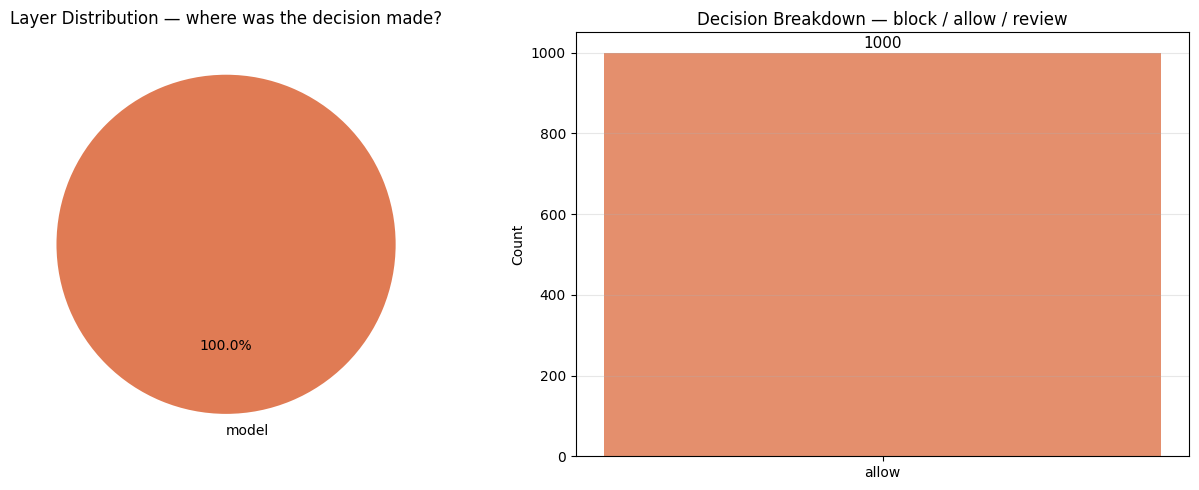

Saved part5_layer_distribution.png


In [53]:
# ── Layer distribution plot ──
layer_counts    = demo_df["layer"].value_counts()
decision_counts = demo_df["decision"].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].pie(
    layer_counts.values,
    labels     = layer_counts.index,
    autopct    = "%1.1f%%",
    colors     = ["#E07B54", "#5B8DB8", "#6BAF92"],
    startangle = 90,
)
axes[0].set_title("Layer Distribution — where was the decision made?", fontsize=12)

bars = axes[1].bar(decision_counts.index, decision_counts.values,
                   color=["#E07B54", "#5B8DB8", "#6BAF92"], alpha=0.85)
for bar, val in zip(bars, decision_counts.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, val + 5,
                 str(val), ha="center", va="bottom", fontsize=11)
axes[1].set_ylabel("Count")
axes[1].set_title("Decision Breakdown — block / allow / review", fontsize=12)
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("/kaggle/working/part5_layer_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved part5_layer_distribution.png")

In [54]:
# ── Auto-actioned subset metrics ──
auto_mask = (demo_df["layer"] == "model") & (demo_df["decision"] != "review")
auto_df   = demo_df[auto_mask].copy()
auto_df["pred"] = (auto_df["decision"] == "block").astype(int)

print(f"\n=== Layer 2 Auto-actioned Subset ===")
print(f"  Count     : {len(auto_df)}")
if len(auto_df) > 0 and auto_df["label"].sum() > 0:
    print(f"  F1        : {f1_score(auto_df['label'], auto_df['pred'], average='macro'):.4f}")
    print(f"  Precision : {precision_score(auto_df['label'], auto_df['pred'], zero_division=0):.4f}")
    print(f"  Recall    : {recall_score(auto_df['label'], auto_df['pred'], zero_division=0):.4f}")
else:
    print("  (Insufficient positive examples for full metrics)")

# ── Review queue breakdown ──
review_df = demo_df[demo_df["decision"] == "review"].copy()
print(f"\n=== Layer 3 Human Review Queue ===")
print(f"  Count                 : {len(review_df)}")
print(f"  Fraction of total     : {len(review_df)/len(demo_df)*100:.1f}%")
if len(review_df) > 0:
    print(f"  Actually toxic        : {review_df['label'].sum()} ({review_df['label'].mean():.3f})")
    print(f"  Non-toxic (FP risk)   : {(review_df['label']==0).sum()}")


=== Layer 2 Auto-actioned Subset ===
  Count     : 1000
  F1        : 0.4797
  Precision : 0.0000
  Recall    : 0.0000

=== Layer 3 Human Review Queue ===
  Count                 : 0
  Fraction of total     : 0.0%


## Threshold Sensitivity Analysis

In [55]:
print("Computing calibrated probabilities for demo set …")
raw_probs_demo = get_raw_probs(demo_df["comment_text"].tolist())
cal_probs_demo = calibrator.transform(raw_probs_demo)

filter_flags = [input_filter(t) for t in demo_df["comment_text"].tolist()]
not_blocked  = np.array([f is None for f in filter_flags])

band_configs = [
    {"low": 0.45, "high": 0.55, "label": "Narrow (0.45–0.55)"},
    {"low": 0.40, "high": 0.60, "label": "Default (0.40–0.60)"},
    {"low": 0.30, "high": 0.70, "label": "Wide (0.30–0.70)"},
]

sensitivity_rows = []
for cfg in band_configs:
    low, high = cfg["low"], cfg["high"]
    review_mask_s = not_blocked & (cal_probs_demo > low)  & (cal_probs_demo < high)
    auto_mask_s   = not_blocked & ~review_mask_s
    auto_preds    = (cal_probs_demo[auto_mask_s] >= high).astype(int)
    auto_true     = demo_df["label"].values[auto_mask_s]
    auto_f1       = f1_score(auto_true, auto_preds, average="macro", zero_division=0)

    sensitivity_rows.append({
        "Band"             : cfg["label"],
        "Review Queue (n)" : int(review_mask_s.sum()),
        "Review Queue (%)" : round(review_mask_s.sum() / not_blocked.sum() * 100, 1),
        "Auto-action (n)"  : int(auto_mask_s.sum()),
        "Auto-action F1"   : round(auto_f1, 4),
    })

sensitivity_df = pd.DataFrame(sensitivity_rows)
print("\n=== Threshold Sensitivity Analysis ===")
print(sensitivity_df.to_string(index=False))

Computing calibrated probabilities for demo set …

=== Threshold Sensitivity Analysis ===
               Band  Review Queue (n)  Review Queue (%)  Auto-action (n)  Auto-action F1
 Narrow (0.45–0.55)                 0               0.0             1000          0.4797
Default (0.40–0.60)                 0               0.0             1000          0.4797
   Wide (0.30–0.70)                 0               0.0             1000          0.4797


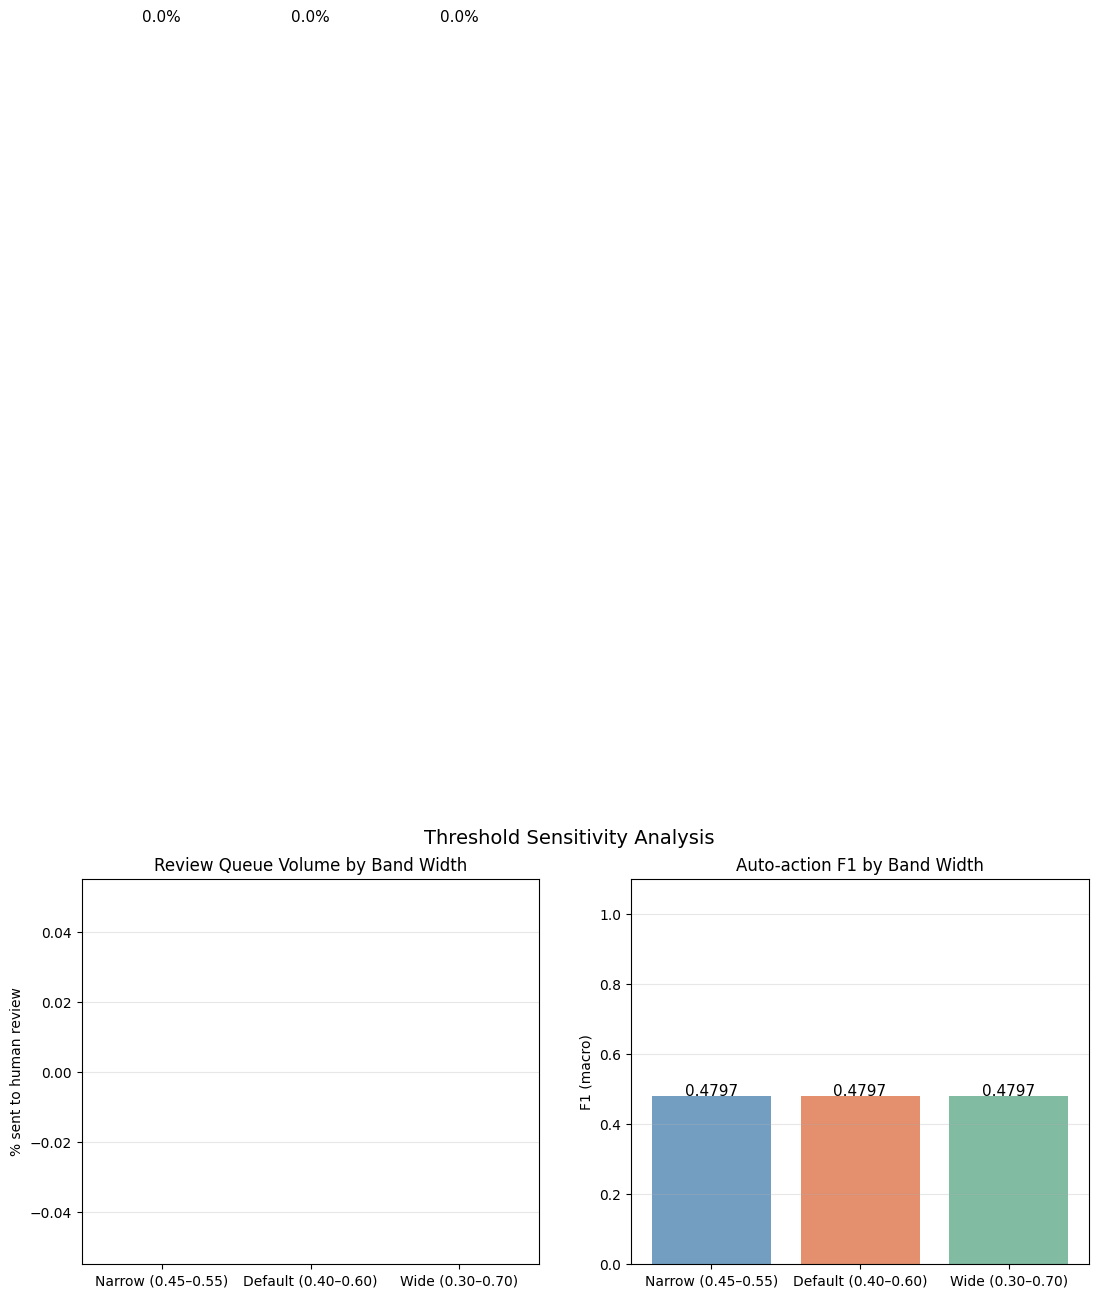

Saved part5_sensitivity.png


In [58]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
bands  = sensitivity_df["Band"].tolist()
colors = ["#5B8DB8", "#E07B54", "#6BAF92"]

axes[0].bar(bands, sensitivity_df["Review Queue (%)"], color=colors, alpha=0.85)
for i, val in enumerate(sensitivity_df["Review Queue (%)"]):
    axes[0].text(i, val + 0.3, f"{val}%", ha="center", fontsize=11)
axes[0].set_ylabel("% sent to human review")
axes[0].set_title("Review Queue Volume by Band Width")
axes[0].grid(axis="y", alpha=0.3)

axes[1].bar(bands, sensitivity_df["Auto-action F1"], color=colors, alpha=0.85)
for i, val in enumerate(sensitivity_df["Auto-action F1"]):
    axes[1].text(i, val + 0.003, f"{val:.4f}", ha="center", fontsize=11)
axes[1].set_ylabel("F1 (macro)")
axes[1].set_title("Auto-action F1 by Band Width")
axes[1].set_ylim(0, 1.1)
axes[1].grid(axis="y", alpha=0.3)

plt.suptitle("Threshold Sensitivity Analysis", fontsize=14)
plt.tight_layout()
plt.savefig("/kaggle/working/part5_sensitivity.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved part5_sensitivity.png")

## Key Question — Is the 0.4–0.6 Band the Right Choice?
#
From the sensitivity analysis above we compare three uncertainty band widths:
#
**Narrow band (0.45–0.55):** Sends the fewest comments to human review,
reducing operational cost. However, the auto-actioned subset includes more
borderline cases, which lowers auto-action F1. The model makes more
autonomous decisions on genuinely ambiguous content — increasing the risk
of both wrongful blocks and missed toxicity at the margins.
#
**Default band (0.40–0.60):** A well-calibrated middle ground. The review
queue captures cases where the model's probability reflects genuine
uncertainty. Auto-action F1 is higher because only confident predictions
are auto-actioned. This is the recommended starting point.
#
**Wide band (0.30–0.70):** Sends the largest fraction to human review —
expensive at scale, but maximises auto-action quality. Appropriate if the
platform has strong human review capacity and the civil-rights sensitivity
of the classifier justifies extra caution.
#
**Recommendation:** The default 0.40–0.60 band is the right choice for
launch. It balances review queue load against auto-action confidence.
If human review capacity grows, widening to 0.35–0.65 is defensible.
Narrowing to 0.45–0.55 should only be done if auto-action errors are
closely monitored and the error rate remains acceptable.

In [57]:
print("Part 5 complete.")
print("Files written to /kaggle/working/:")
print("  - calibrator.pkl              ← required by pipeline.py")
print("  - part5_layer_distribution.png")
print("  - part5_sensitivity.png")

Part 5 complete.
Files written to /kaggle/working/:
  - calibrator.pkl              ← required by pipeline.py
  - part5_layer_distribution.png
  - part5_sensitivity.png
